In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


In [3]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 3))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407

ROC-AUC: 0.836


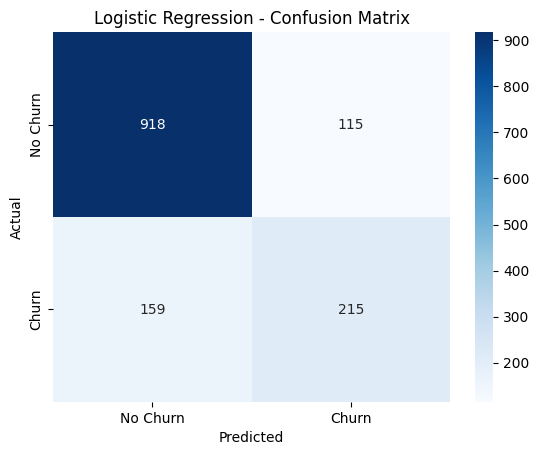

In [4]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title("Logistic Regression - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Logistic Regression Baseline:
- ROC-AUC: 0.836
- False Positives: 115

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'   # handles class imbalance
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.817


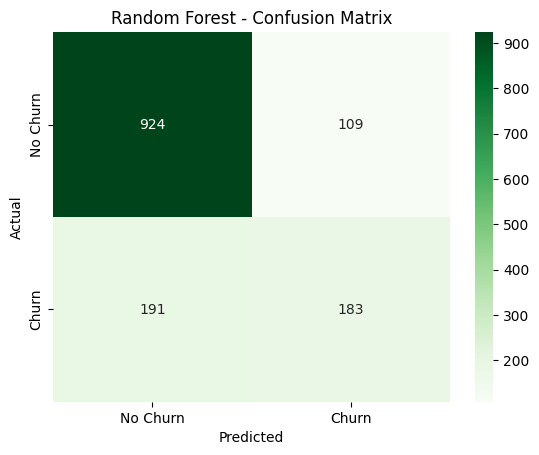

In [6]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title("Random Forest - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Random Forest Baseline:
- ROC-AUC: 0.817
- False Positives: 109

In [7]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=3,    # handles class imbalance (roughly non-churn/churn ratio)
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb),3)

c:\Users\sudha\Desktop\churn-prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:23:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.70      1407
weighted avg       0.78      0.75      0.76      1407

ROC-AUC: 0.8156374404025448 3


In [8]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=3,    # handles class imbalance (roughly non-churn/churn ratio)
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb),3)

c:\Users\sudha\Desktop\churn-prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:23:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.70      1407
weighted avg       0.78      0.75      0.76      1407

ROC-AUC: 0.8156374404025448 3


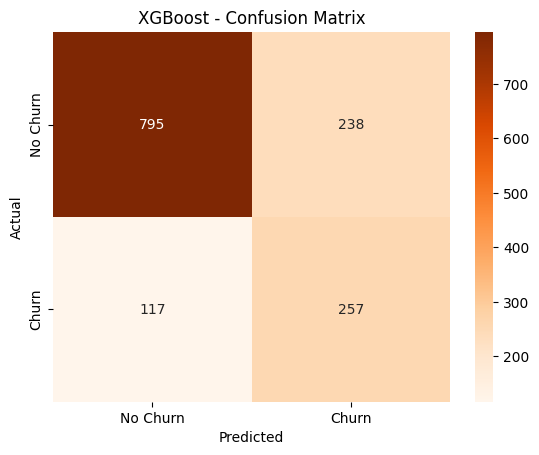

In [9]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title("XGBoost - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

Xg boost Baseline:
- ROC-AUC: 0.815
- False Positives: 238

#Tuned UP Models

In [15]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    lr_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)

print("Best LR params:", lr_grid.best_params_)
print("Best LR AUC:", lr_grid.best_score_.round(3))

Best LR params: {'C': 10, 'solver': 'liblinear'}
Best LR AUC: 0.846


In [16]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF AUC:", rf_grid.best_score_.round(3))

Best RF params: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 2, 'n_estimators': 200}
Best RF AUC: 0.847


In [22]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'scale_pos_weight': [scale]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB AUC:", xgb_grid.best_score_.round(3))

Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': np.float64(2.762541806020067)}
Best XGB AUC: 0.846


Best models and charts


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.835


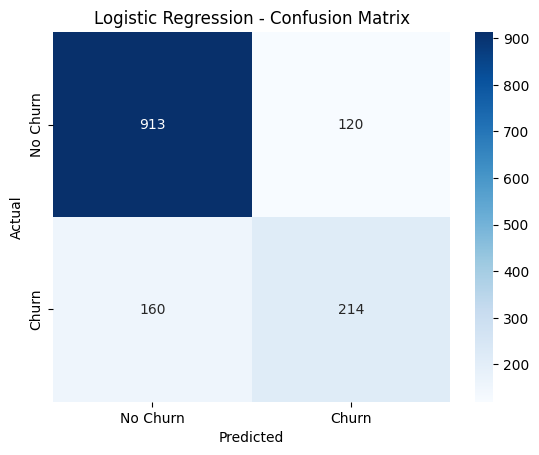


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

ROC-AUC: 0.839


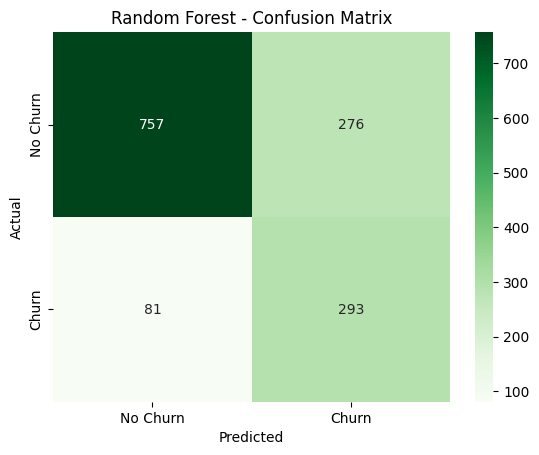


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.91      0.71      0.79      1033
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

ROC-AUC: 0.839


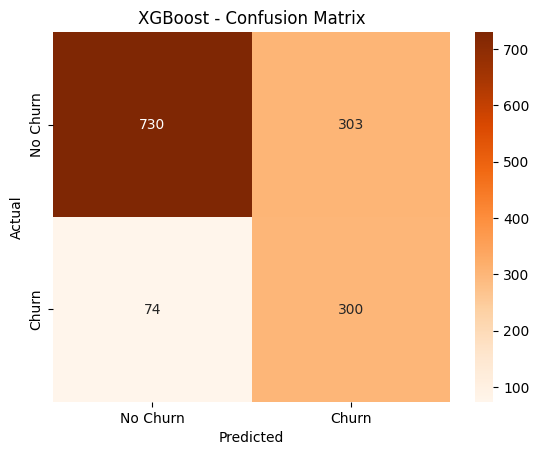

In [23]:
# Get the best models from grid search
best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

# Evaluate all three on test set
models = {
    'Logistic Regression': (best_lr, 'Blues'),
    'Random Forest': (best_rf, 'Greens'),
    'XGBoost': (best_xgb, 'Oranges')
}

for name, (model, color) in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

ROC Curve

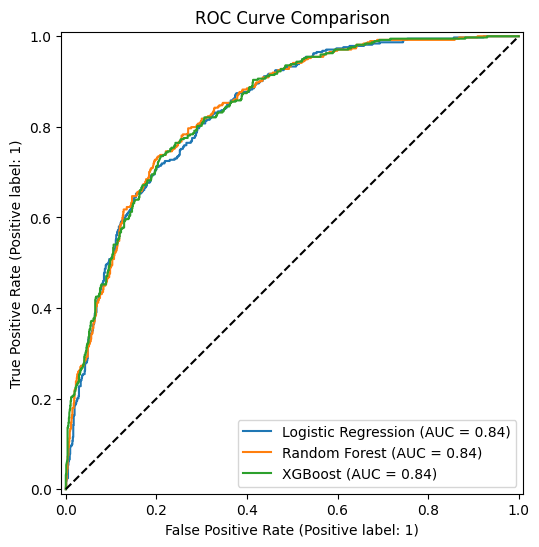

In [24]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, (model, _) in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title("ROC Curve Comparison")
plt.show()

Saving Model

In [25]:
import pickle

with open("../models/best_model_rf.pkl", "wb") as f:
    pickle.dump(best_rf, f)

print("Model saved!")

Model saved!
